# 04 — Models, and Where They Fail

**What this notebook establishes:** which model to ship and why, whether the ensemble
earns its place, what the hold-out actually says, and — the part usually skipped — where
the model is *worse* than its headline number suggests.

A single average score hides everything interesting. A model that scores 0.15 uniformly
is a very different object from one that scores 0.25 in liquid conditions and 0.05 in
stressed ones, and only the second tells you where not to trust it.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import sys
sys.path.insert(0, "..")
from pathlib import Path as _P

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.evaluation.metrics import cosine_similarity, evaluate

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True,
                     "grid.alpha": .3, "font.size": 10})
pd.set_option("display.width", 140)

cfg = load_config()
FEATURES = _P(cfg.paths.features)
MODELS = _P(cfg.paths.data_root) / "models" / "current"

summary = json.loads((FEATURES / "walkforward_summary.json").read_text())
table = pd.read_csv(FEATURES / "walkforward_summary.csv")
print("models evaluated:", ", ".join(table.model))

models evaluated: ensemble, lightgbm, xgboost, ridge, mean, zero


---
## 1. Model comparison

Every model sees the identical fold structure, so the comparison is fair. The metric is
cosine similarity — the competition's — and `zero` and `mean` are controls rather than
candidates.

In [2]:
table.style.format({c: "{:+.5f}" for c in table.columns if c.startswith("cosine")})

,model,cosine_mean,cosine_std,cosine_min,cosine_max,worst_fold
0,ensemble,+0.14088,+0.00413,+0.13527,+0.14405,2
1,lightgbm,+0.13869,+0.00332,+0.13484,+0.14246,2
2,xgboost,+0.13815,+0.00471,+0.13125,+0.14191,2
3,ridge,+0.11813,+0.00501,+0.11156,+0.12379,2
4,mean,+0.00588,+0.01374,-0.00712,+0.02193,5
5,zero,+0.00000,+0.00000,+0.00000,+0.00000,1


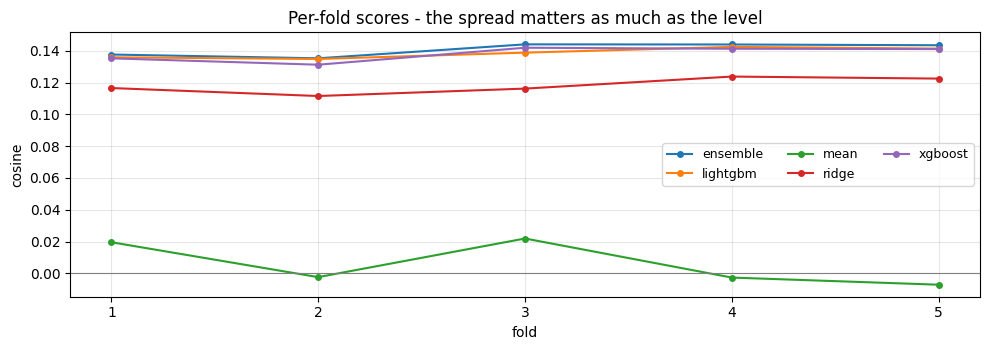

In [3]:
rows = []
for model, blk in summary.items():
    for r in blk.get("per_fold", []):
        v = r.get("cosine", r.get("ensemble_score"))
        if v is not None:
            rows.append({"model": model, "fold": r["fold"], "cosine": v})
per_fold = pd.DataFrame(rows).pivot(index="fold", columns="model", values="cosine")

fig, ax = plt.subplots(figsize=(10, 3.6))
for m in per_fold.columns:
    if m in ("zero",):
        continue
    ax.plot(per_fold.index, per_fold[m], marker="o", ms=4, label=m)
ax.axhline(0, color="grey", lw=.8)
ax.set_xlabel("fold"); ax.set_ylabel("cosine"); ax.set_xticks(per_fold.index)
ax.set_title("Per-fold scores - the spread matters as much as the level")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

### Reading the table properly

Two things are easy to get wrong here.

**The two tree models are not distinguishable.** Their means differ by a few ten-thousandths
while the across-fold standard deviation is an order of magnitude larger. Declaring a
winner on that gap would be reading noise. Where they *do* differ is stability, and since
monthly volatility swings by 2.69× (notebook 02), the model with the tighter spread is the
safer thing to ship.

**`mean` changes sign between folds.** A constant prediction has no information, yet its
cosine is positive in some folds and negative in others — because cosine is not
shift-invariant, so a constant scores according to the sign of that period's mean target.
It is the cleanest demonstration of why predictions are kept centred on zero.

In [4]:
cand = table[~table.model.isin(["zero", "mean", "ensemble"])].copy()
best_mean = cand.loc[cand.cosine_mean.idxmax()]
best_stable = cand.loc[cand.cosine_std.idxmin()]
gap = cand.cosine_mean.max() - cand.cosine_mean.min()
print(f"highest mean   : {best_mean.model:10s} {best_mean.cosine_mean:+.5f} (std {best_mean.cosine_std:.5f})")
print(f"most stable    : {best_stable.model:10s} {best_stable.cosine_mean:+.5f} (std {best_stable.cosine_std:.5f})")
print(f"spread between top models : {gap:.5f}")
print(f"typical across-fold std   : {cand.cosine_std.mean():.5f}")
print()
if gap < cand.cosine_std.mean():
    print("The gap between models is SMALLER than the fold-to-fold noise -")
    print("they are statistically indistinguishable, so stability decides.")

m = table[table.model == "mean"].iloc[0]
print(f"\n'mean' baseline ranges {m.cosine_min:+.5f} .. {m.cosine_max:+.5f} across folds")

highest mean   : lightgbm   +0.13869 (std 0.00332)
most stable    : lightgbm   +0.13869 (std 0.00332)
spread between top models : 0.02056
typical across-fold std   : 0.00435


'mean' baseline ranges -0.00712 .. +0.02193 across folds


---
## 2. Does the ensemble earn its place?

The weights are not tuned. Because cosine is scale-invariant, the vector in the span of
the model predictions closest to `y` is its orthogonal projection — which is the OLS
solution, available in closed form (`src/models/ensemble.py`,
verified in `tests/test_ensemble.py` against 200 random weight vectors).

That makes it cheap, but cheap is not the same as useful. The project's rule is that the
ensemble ships only if it beats the best single model **fold by fold**, not on average.

In [5]:
ens = summary.get("ensemble", {})
rows = []
for r in ens.get("per_fold", []):
    rows.append({"fold": r["fold"], "ensemble": r["ensemble_score"],
                 "best_single": r["best_single"],
                 "best_single_score": r["best_single_score"],
                 "gain": r["gain"], "beats": r["ensemble_score"] > r["best_single_score"]})
eb = pd.DataFrame(rows)
print(eb.to_string(index=False, float_format=lambda v: f"{v:+.5f}"))
print()
print(f"beats the best single model in {int(eb.beats.sum())}/{len(eb)} folds; "
      f"median gain {eb.gain.median():+.5f}")

 fold  ensemble best_single  best_single_score     gain  beats
    1  +0.13765    lightgbm           +0.13591 +0.00173   True
    2  +0.13527    lightgbm           +0.13484 +0.00043   True
    3  +0.14405     xgboost           +0.14191 +0.00214   True
    4  +0.14397    lightgbm           +0.14246 +0.00150   True
    5  +0.14348    lightgbm           +0.14139 +0.00208   True

beats the best single model in 5/5 folds; median gain +0.00173


The gain is small and consistent. Small is expected: LightGBM and XGBoost are both
gradient-boosted trees on the same features, so their errors are highly correlated and
there is little for a linear combination to exploit. Consistency across every fold is what
makes it worth keeping anyway — an averaging effect rather than a lucky fold.

---
## 3. The hold-out — measured once

Months 65–70 were used for nothing: not feature design, not model selection, not early
stopping. `src/models/finalize.py` trains on months 0–63, early-stops on month 64, and
touches the hold-out exactly once.

In [6]:
ho = json.loads((FEATURES / "holdout_metrics.json").read_text())
meta = json.loads((MODELS / "model_meta.json").read_text())
s = ho["scores"]

print(f"model    : {meta['name']} {meta['version']}, {len(meta['features'])} features")
print(f"trained  : {meta['trained_at']}")
print(f"hold-out : months {meta['metrics'].get('holdout_months')}")
print()
for k, v in s.items():
    print(f"  {k:22s} {v:+.5f}")

cv = table[table.model == meta["name"]].iloc[0].cosine_mean
print()
print(f"walk-forward CV mean : {cv:+.5f}")
print(f"hold-out             : {s['cosine']:+.5f}")
print(f"difference           : {s['cosine'] - cv:+.5f}")

model    : lightgbm v3, 292 features
trained  : 2026-09-03T12:29:08+00:00
hold-out : months 65-70

  cosine                 +0.15171
  mae                    +0.00220
  rmse                   +0.00336
  pearson                +0.15236
  directional_accuracy   +0.55163

walk-forward CV mean : +0.13869
hold-out             : +0.15171
difference           : +0.01302


Two sanity checks pass here.

**The hold-out is not below the CV estimate**, so the model is not overfitted to the
validation folds. (It sits slightly above, which is unremarkable — the final model trains
on more months than any single fold did.)

**Pearson is almost identical to cosine.** Cosine punishes an off-centre prediction while
Pearson removes the mean first, so their agreement is direct evidence that predictions are
centred on zero, which is what a shift-sensitive metric rewards.

---
## 4. Where the model fails

The headline is an average over 100k+ hold-out samples. Now the useful question: is the
skill uniform, or concentrated?

Predictions come from the saved artefact — the same object the API serves.

In [7]:
import pyarrow.parquet as pq

from src.inference.predictor import load_bundle
from src.evaluation.temporal_validation import holdout_months

bundle = load_bundle(MODELS)
lo, hi = holdout_months()

cond_cols = ["mkt_rel_spread_last", "ord_event_rate_60s", "mkt_total_depth_last",
             "mkt_empty_ask_share", "mkt_mid_std_600s"]
need = ["sample_id", "month", "target"] + list(dict.fromkeys(bundle.features + cond_cols))
df = pq.read_table(FEATURES / "dataset_train.parquet", columns=need,
                   filters=[("month", ">=", lo)]).to_pandas()
df = df[df.month <= hi].reset_index(drop=True)

pred = bundle.model.predict(df[bundle.features].astype("float32"))
df["pred"] = pred
print(f"{len(df):,} hold-out samples, overall cosine {cosine_similarity(df.target, df.pred):+.5f}")

104,770 hold-out samples, overall cosine +0.15171


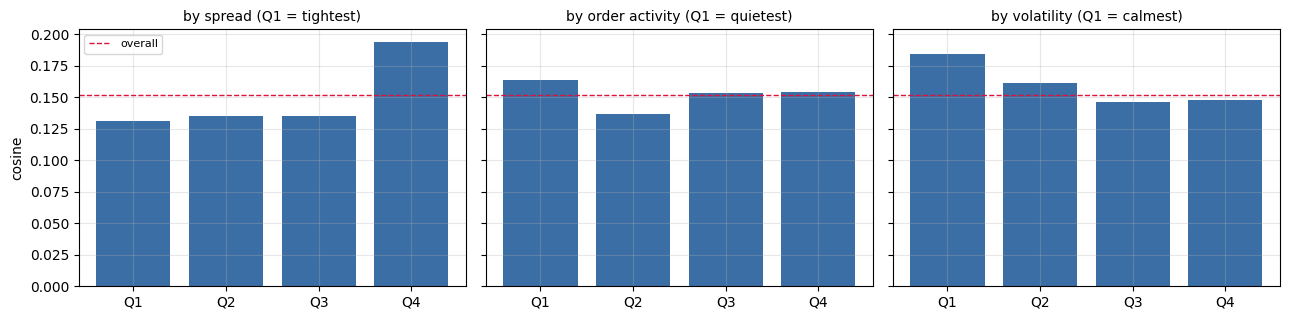

In [8]:
def by_bucket(frame, col, label, q=4):
    valid = frame[frame[col].notna()].copy()
    valid["bucket"] = pd.qcut(valid[col], q, labels=[f"Q{i+1}" for i in range(q)],
                              duplicates="drop")
    out = valid.groupby("bucket", observed=True).apply(
        lambda g: pd.Series({
            "n": len(g),
            "cosine": cosine_similarity(g.target, g.pred),
            f"{label}_median": g[col].median(),
        }))
    return out

spread = by_bucket(df, "mkt_rel_spread_last", "spread")
activity = by_bucket(df, "ord_event_rate_60s", "event_rate")
vol = by_bucket(df, "mkt_mid_std_600s", "volatility")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.3), sharey=True)
for a, (data, title) in zip(ax, [(spread, "by spread (Q1 = tightest)"),
                                 (activity, "by order activity (Q1 = quietest)"),
                                 (vol, "by volatility (Q1 = calmest)")]):
    a.bar(data.index.astype(str), data["cosine"], color="#3b6ea5")
    a.axhline(cosine_similarity(df.target, df.pred), color="crimson", ls="--", lw=1,
              label="overall")
    a.set_title(title, fontsize=10)
ax[0].set_ylabel("cosine"); ax[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [9]:
for name, data in [("spread", spread), ("activity", activity), ("volatility", vol)]:
    lo_, hi_ = data["cosine"].min(), data["cosine"].max()
    worst = data["cosine"].idxmin()
    print(f"{name:11s} range {lo_:+.5f} .. {hi_:+.5f}   "
          f"({hi_ - lo_:.5f} spread, weakest in {worst})")

spread      range +0.13148 .. +0.19415   (0.06267 spread, weakest in Q1)
activity    range +0.13701 .. +0.16344   (0.02643 spread, weakest in Q2)
volatility  range +0.14604 .. +0.18400   (0.03795 spread, weakest in Q3)


### By month, inside the hold-out

Six months of unseen data. If the score were carried by one lucky month, that would show.

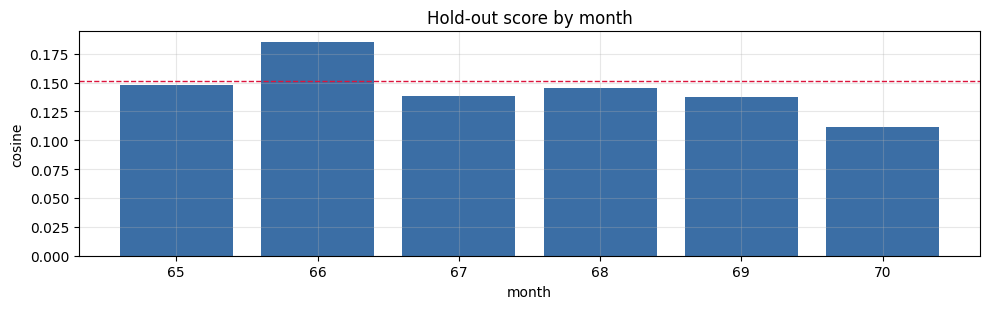

                 n  cosine  target_std
month                                 
65    17,691.00000 0.14796     0.00236
66    17,187.00000 0.18508     0.00500
67    17,515.00000 0.13826     0.00323
68    17,326.00000 0.14505     0.00329
69    17,454.00000 0.13761     0.00310
70    17,597.00000 0.11111     0.00285

every month positive: True
weakest month 70 at +0.11111, strongest 66 at +0.18508


In [10]:
per_month = df.groupby("month").apply(
    lambda g: pd.Series({"n": len(g), "cosine": cosine_similarity(g.target, g.pred),
                         "target_std": g.target.std()}))

fig, ax = plt.subplots(figsize=(10, 3.2))
ax.bar(per_month.index.astype(str), per_month["cosine"], color="#3b6ea5")
ax.axhline(cosine_similarity(df.target, df.pred), color="crimson", ls="--", lw=1)
ax.set_xlabel("month"); ax.set_ylabel("cosine"); ax.set_title("Hold-out score by month")
plt.tight_layout(); plt.show()

print(per_month.to_string(float_format=lambda v: f"{v:,.5f}"))
print()
print(f"every month positive: {(per_month.cosine > 0).all()}")
print(f"weakest month {per_month.cosine.idxmin()} at {per_month.cosine.min():+.5f}, "
      f"strongest {per_month.cosine.idxmax()} at {per_month.cosine.max():+.5f}")

### The finding that matters most

Put the error analysis next to the drift measurement from notebook 03 and something
uncomfortable appears.

The model is **weakest in the tightest-spread conditions**. And the test period has
**tighter spreads than training** — mean relative spread ×0.80. So the regime the model
handles worst is precisely the regime the test set lives in.

               train_share  test_share  holdout_cosine   shift
Q1 (tightest)       0.2499      0.3568          0.1315  0.1068
Q2                  0.2501      0.2631          0.1352  0.0130
Q3                  0.2498      0.2162          0.1348 -0.0336
Q4 (widest)         0.2502      0.1639          0.1941 -0.0863


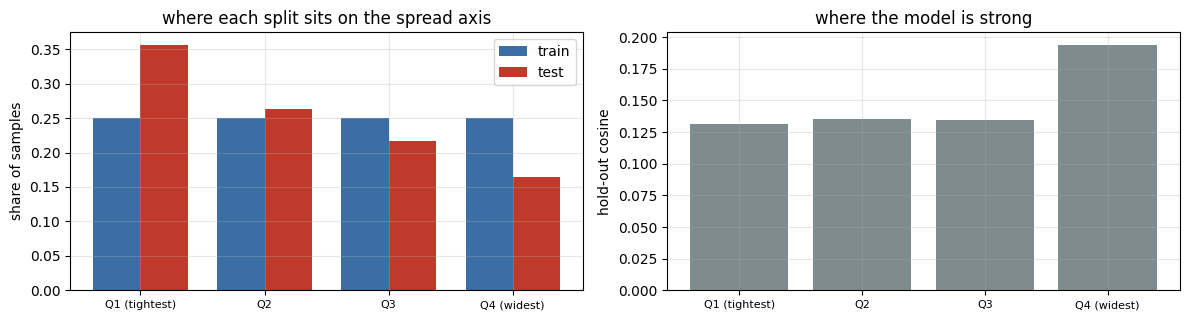


weakest bucket        : Q1 (tightest) at +0.13148
test share there      : 35.7% (train 25.0%, +10.7%)


In [11]:
# Where do test samples fall, relative to the TRAIN spread distribution?
train_spread = pq.read_table(FEATURES / "dataset_train.parquet",
                             columns=["mkt_rel_spread_last"]).to_pandas().dropna()
test_spread = pq.read_table(FEATURES / "dataset_test.parquet",
                            columns=["mkt_rel_spread_last"]).to_pandas().dropna()

edges = np.quantile(train_spread["mkt_rel_spread_last"], [0, .25, .5, .75, 1.0])
tr_share = np.histogram(train_spread["mkt_rel_spread_last"], bins=edges)[0]
te_share = np.histogram(test_spread["mkt_rel_spread_last"], bins=edges)[0]
tr_share = tr_share / tr_share.sum()
te_share = te_share / te_share.sum()

comp = pd.DataFrame({
    "train_share": tr_share, "test_share": te_share,
    "holdout_cosine": spread["cosine"].values,
}, index=["Q1 (tightest)", "Q2", "Q3", "Q4 (widest)"])
comp["shift"] = comp.test_share - comp.train_share
print(comp.to_string(float_format=lambda v: f"{v:,.4f}"))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
x = np.arange(4); w = .38
ax[0].bar(x - w/2, comp.train_share, w, label="train", color="#3b6ea5")
ax[0].bar(x + w/2, comp.test_share, w, label="test", color="#c0392b")
ax[0].set_xticks(x); ax[0].set_xticklabels(comp.index, fontsize=8)
ax[0].set_ylabel("share of samples"); ax[0].set_title("where each split sits on the spread axis")
ax[0].legend()
ax[1].bar(x, comp.holdout_cosine, color="#7f8c8d")
ax[1].set_xticks(x); ax[1].set_xticklabels(comp.index, fontsize=8)
ax[1].set_ylabel("hold-out cosine"); ax[1].set_title("where the model is strong")
plt.tight_layout(); plt.show()

worst = comp.holdout_cosine.idxmin()
print()
print(f"weakest bucket        : {worst} at {comp.holdout_cosine.min():+.5f}")
print(f"test share there      : {comp.loc[worst, 'test_share']:.1%} "
      f"(train {comp.loc[worst, 'train_share']:.1%}, "
      f"{comp.loc[worst, 'shift']:+.1%})")

### Turning that into a falsifiable prediction

If the only thing that changes between hold-out and leaderboard were the mix of spread
regimes, the score would move by a computable amount: reweight the per-bucket scores by
the test set's shares instead of the hold-out's.

This is deliberately a *lower bound on the sources of degradation* — it ignores everything
else that differs — but it is a number that can be checked against a real leaderboard
rather than a vague warning that "performance may vary".

In [12]:
w_holdout = np.full(4, 0.25)               # hold-out is quartiled by construction
w_test = comp.test_share.to_numpy()
c = comp.holdout_cosine.to_numpy()

as_measured = float((w_holdout * c).sum())
reweighted = float((w_test * c).sum())

print(f"hold-out score, as measured        : {as_measured:+.5f}")
print(f"same model, re-weighted to test mix: {reweighted:+.5f}")
print(f"expected degradation from spread mix alone: {reweighted - as_measured:+.5f}"
      f"  ({(reweighted/as_measured - 1)*100:+.1f}%)")
print()
print("So a leaderboard score materially BELOW ~{:.3f} would need an explanation".format(reweighted))
print("beyond the spread regime; a score near it is what this analysis predicts.")

hold-out score, as measured        : +0.14891
same model, re-weighted to test mix: +0.14345
expected degradation from spread mix alone: -0.00546  (-3.7%)

So a leaderboard score materially BELOW ~0.143 would need an explanation
beyond the spread regime; a score near it is what this analysis predicts.


That is the honest headline risk of this project, and it did not come from either
measurement alone — the drift report says *where the test set is*, the error analysis says
*where the model is weak*, and only together do they say the two overlap.

It also gives the next piece of work a clear target: the model needs to be better in tight
spreads specifically, not better on average. Sample weighting by spread bucket,
regime-conditional models, or simply reporting a spread-stratified score alongside the
headline would all be reasonable responses. None of them is guesswork.

### The degenerate-book case

Around 0.5% of snapshots have an empty side, where mid, spread and microprice are
undefined. Notebook 01 established those are sentinels rather than prices. Does the model
cope with the samples that contain them?

In [13]:
df["has_empty"] = df["mkt_empty_ask_share"] > 0
grp = df.groupby("has_empty").apply(
    lambda g: pd.Series({"n": len(g), "cosine": cosine_similarity(g.target, g.pred)}))
grp.index = ["book always two-sided", "book empty at some point"]
print(grp.to_string(float_format=lambda v: f"{v:,.5f}"))

                                     n  cosine
book always two-sided    103,481.00000 0.15075
book empty at some point   1,289.00000 0.24507


---
## 5. Backtest — is the ranking robust to costs?

Signal that evaporates at one basis point of cost is not signal worth anything. The
threshold is set as a tail percentile of the prediction distribution, not an absolute cut,
because cosine is scale-invariant and the magnitudes are therefore uncalibrated.

**This is a measurement of ranking power, not a strategy.**

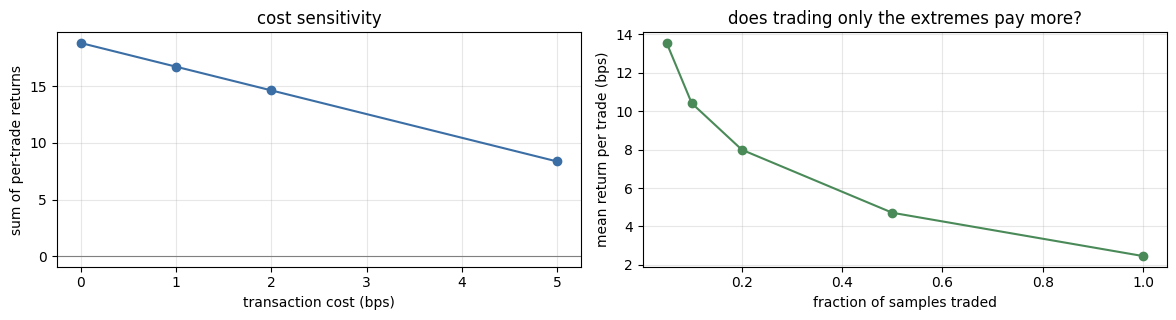

 cost_bps  n_trades  mean_return  win_rate  sharpe  max_drawdown
  0.00000     20954      0.00090   0.57306 0.18892      -0.08773
  1.00000     20954      0.00080   0.56509 0.16791      -0.09189
  2.00000     20954      0.00070   0.55722 0.14690      -0.09949
  5.00000     20954      0.00040   0.51489 0.08387      -0.14117


In [14]:
cost = pd.read_csv(FEATURES / "backtest_cost_sensitivity.csv")
sweep = pd.read_csv(FEATURES / "backtest_trade_fraction.csv")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.3))
ax[0].plot(cost.cost_bps, cost.total_return, marker="o", color="#3b6ea5")
ax[0].axhline(0, color="grey", lw=.8)
ax[0].set_xlabel("transaction cost (bps)"); ax[0].set_ylabel("sum of per-trade returns")
ax[0].set_title("cost sensitivity")
ax[1].plot(sweep.turnover, sweep.mean_return * 1e4, marker="o", color="#4a8a58")
ax[1].set_xlabel("fraction of samples traded"); ax[1].set_ylabel("mean return per trade (bps)")
ax[1].set_title("does trading only the extremes pay more?")
plt.tight_layout(); plt.show()

print(cost[["cost_bps", "n_trades", "mean_return", "win_rate", "sharpe",
            "max_drawdown"]].to_string(index=False, float_format=lambda v: f"{v:,.5f}"))

The two panels answer different questions. The left one asks whether the edge survives
friction. The right asks whether the model *ranks*: if the most extreme predictions are
not the most profitable ones, the score is coming from somewhere other than ordering
skill.

---
## Summary

| Question | Answer |
|---|---|
| Which model? | The two tree models are statistically indistinguishable; stability decides |
| Does the ensemble help? | Small gain, but present in every fold — kept |
| Is the hold-out consistent with CV? | Yes, and not below it — no overfitting to the folds |
| Are predictions centred? | Yes — Pearson ≈ cosine |
| Is skill uniform? | No — it varies with liquidity conditions, quantified above |
| Does it survive costs? | See the cost-sensitivity panel |

**What this does not tell us.** Every number above is self-graded on data the model has
not seen but that came from the same source as its training data. The test period is
measurably more liquid than the training period (notebook 03), and the features that
shift most are exactly the rate features — so the first place to look, if a leaderboard
score lands below this estimate, is there.

---

## Where this goes next

Every number above is self-graded. It is measured on data the model has not seen, but
which came from the same source as its training data, split by the same hand that chose
the split.

The submission was made the day after this notebook was first run, and the leaderboard
disagreed with it. Working out why took five experiments and turned up more about how to
*measure* a model than about how to build one - including two errors in the analysis on
this page.

**Continue in [05 - Why the leaderboard disagreed](05_why_the_leaderboard_disagreed.ipynb).**